## TikTok Billboard Analysis
### by Violet Fiorella

This project predicts whether a viral TikTok song will appear on the Billboard Hot 100. Is TikTok a good metric for predicting commercial success?  

## 1. Data Loading

In [1]:
import pandas as pd
import kagglehub
import os
import re

In [2]:
# TikTok Song Data
tiktok_2019 = kagglehub.dataset_download("sveta151/tiktok-popular-songs-2019")
tiktok_2020 = kagglehub.dataset_download("sveta151/tiktok-popular-songs-2020")
tiktok_2021 = kagglehub.dataset_download("sveta151/tiktok-popular-songs-2021")
tiktok_2022 = kagglehub.dataset_download("sveta151/tiktok-popular-songs-2022")

df_2019 = pd.read_csv(f"{tiktok_2019}/TikTok_songs_2019.csv")
df_2020 = pd.read_csv(f"{tiktok_2020}/TikTok_songs_2020.csv")
df_2021 = pd.read_csv(f"{tiktok_2021}/TikTok_songs_2021.csv")
df_2022 = pd.read_csv(f"{tiktok_2022}/TikTok_songs_2022.csv")

print("TikTok datasets loaded:")
print(f"2019: {df_2019.shape}, 2020: {df_2020.shape}, 2021: {df_2021.shape}, 2022: {df_2022.shape}")

TikTok datasets loaded:
2019: (223, 18), 2020: (292, 18), 2021: (190, 18), 2022: (263, 18)


In [3]:
# Billboard Hot 100 Data
billboard_path = kagglehub.dataset_download("dhruvildave/billboard-the-hot-100-songs")
billboard_df = pd.read_csv(f"{billboard_path}/charts.csv")
print(f"Billboard dataset loaded with shape: {billboard_df.shape}")

Billboard dataset loaded with shape: (330087, 7)


## 2. Data Cleaning: TikTok

In [4]:
# Add year column
for i, df_year in enumerate([df_2019, df_2020, df_2021, df_2022], start=2019):
    df_year['year'] = i

# Combine datasets
df = pd.concat([df_2019, df_2020, df_2021, df_2022], ignore_index=True)
df = df.drop_duplicates()
df = df.drop(columns=['album'])
df = df.dropna()

# Remove outliers
numeric_cols = ['danceability','energy','loudness','speechiness','acousticness',
                'instrumentalness','liveness','valence','tempo','duration_ms','track_pop']

for col in numeric_cols:
    mean = df[col].mean()
    std = df[col].std()
    df = df[(df[col] >= mean - 3*std) & (df[col] <= mean + 3*std)]

# Create 'viral' label (defined as a TikTok track having a popularity score of 70 or higher)
df['viral'] = (df['track_pop'] >= 70).astype(int)

print(f"Combined TikTok dataset shape after cleaning: {df.shape}")

Combined TikTok dataset shape after cleaning: (874, 19)


## 3. Data Cleaning: Billboard

In [5]:
# Rename columns for clarity
billboard_df = billboard_df.rename(columns={
    'last-week': 'last_week',
    'peak-rank': 'peak_rank',
    'weeks-on-board': 'weeks_on_board'
})

# Extract year from Billboard date
billboard_df['billboard_year'] = pd.to_datetime(billboard_df['date']).dt.year

# Keep only 2019-2022
billboard_recent = billboard_df[(billboard_df['billboard_year'] >= 2019) & 
                                (billboard_df['billboard_year'] <= 2022)]

print(f"Filtered Billboard dataset 2019-2022: {billboard_recent.shape}")

# Aggregate to one row per song/artist, keeping earliest charting year
billboard_recent = billboard_recent.groupby(['song', 'artist'], as_index=False).agg({
    'peak_rank': 'min',
    'weeks_on_board': 'max',
    'billboard_year': 'min'
})

# Billboard peak rank normalized to a 0-1 score (1 = best rank)
billboard_recent['peak_rank_norm'] = 1 - (billboard_recent['peak_rank'] / 100)

Filtered Billboard dataset 2019-2022: (14900, 8)


In [6]:
def clean_text(name):
    name = str(name).lower().strip()    # Remove parentheses content
    name = re.sub(r'\s*\(.*?\)\s*', '', name)    # Replace & , ; with 'and'
    name = re.sub(r'[&;,]', ' and ', name)    # Remove 'feat' or 'ft'
    name = re.sub(r'\bfeat\b|\bft\b', '', name)    # Remove all non-alphanumeric characters (except space)
    name = re.sub(r'[^a-z0-9\s]', '', name)    # Collapse multiple spaces to single
    name = re.sub(r'\s+', ' ', name)    # Strip again in case of leading/trailing spaces
    name = name.strip()
    return name

# Apply to both datasets
df['track_name_clean'] = df['track_name'].apply(clean_text)
df['artist_name_clean'] = df['artist_name'].apply(clean_text)
billboard_recent['song_clean'] = billboard_recent['song'].apply(clean_text)
billboard_recent['artist_clean'] = billboard_recent['artist'].apply(clean_text)

In [7]:
# Merge TikTok and Billboard datasets
df_merged = df.merge(
    billboard_recent,
    left_on=['track_name_clean', 'artist_name_clean'],
    right_on=['song_clean', 'artist_clean'],
    how='left'
)

# Fill missing Billboard info
df_merged['peak_rank'] = df_merged['peak_rank'].fillna(101)
df_merged['weeks_on_board'] = df_merged['weeks_on_board'].fillna(0)
df_merged['peak_rank_norm'] = df_merged['peak_rank_norm'].fillna(0)

# Binary Billboard indicator
df_merged['charted_billboard'] = df_merged['peak_rank'].apply(lambda x: 1 if x <= 100 else 0)

Songs that charted in a different year than TikTok virality:
                        track_name     artist_name  year  billboard_year  \
0                         Shake It   Metro Station  2019          2008.0   
71                   Yellow Hearts    Ant Saunders  2019          2020.0   
81                         ROXANNE  Arizona Zervas  2019          2020.0   
108      Beggin (original version)          Madcon  2019          2009.0   
118   Put Your Head on My Shoulder       Paul Anka  2019          1959.0   
...                            ...             ...   ...             ...   
5208                           BOP          DaBaby  2022          2020.0   
5226                           BOP          DaBaby  2022          2019.0   
5424                    Without Me          Halsey  2022          2019.0   
5465                    Without Me          Halsey  2022          2018.0   
5476                     Plug Walk    Rich The Kid  2022          2018.0   

      year_lag  
0        

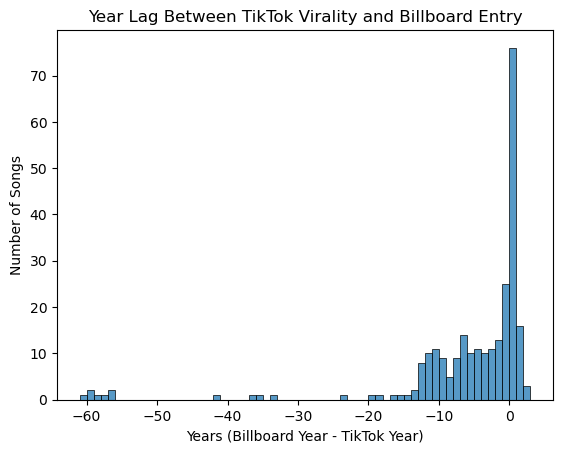

In [8]:
# Time-lag analysis

# Clean Billboard song and artist names
billboard_df['song_clean'] = billboard_df['song'].apply(clean_text)
billboard_df['artist_clean'] = billboard_df['artist'].apply(clean_text)

# Merge TikTok songs with all Billboard entries (not aggregated)
# (Using full Billboard dataset for time-lag analysis because songs may have charted before 2019)
df_merged_full = df.merge(
    billboard_df[['song_clean', 'artist_clean', 'billboard_year', 'peak_rank']],
    left_on=['track_name_clean', 'artist_name_clean'],
    right_on=['song_clean', 'artist_clean'],
    how='left'
)

# Only keep rows that actually charted
df_merged_lag = df_merged_full[df_merged_full['peak_rank'].notna()].copy()

if not df_merged_lag.empty:
    # Compute year lag safely
    df_merged_lag['year_lag'] = df_merged_lag['billboard_year'] - df_merged_lag['year']

    # Deduplicate by track + artist + billboard_year to avoid multiple rows
    df_merged_unique = df_merged_lag.drop_duplicates(subset=['track_name', 'artist_name', 'billboard_year'])

    # Songs that charted in a different year than TikTok virality
    flagged_songs = df_merged_unique[df_merged_unique['year_lag'] != 0]

    if not flagged_songs.empty:
        print("Songs that charted in a different year than TikTok virality:")
        print(flagged_songs[['track_name', 'artist_name', 'year', 'billboard_year', 'year_lag']])
        print(f"\nNumber of unique songs charting in a different year: {flagged_songs['track_name'].nunique()}")
    else:
        print("All charted songs charted in the same year as TikTok virality.")

    # Descriptive stats on unique rows
    num_charted = len(df_merged_unique)
    mean_lag = df_merged_unique['year_lag'].mean()
    median_lag = df_merged_unique['year_lag'].median()
    min_lag = df_merged_unique['year_lag'].min()
    max_lag = df_merged_unique['year_lag'].max()
    neg_lag_count = (df_merged_unique['year_lag'] < 0).sum()
    zero_lag_count = (df_merged_unique['year_lag'] == 0).sum()
    pos_lag_count = (df_merged_unique['year_lag'] > 0).sum()

    # Print stats
    print(f"\nNumber of charted songs considered: {num_charted}")
    print(f"Mean lag (years): {mean_lag:.2f}")
    print(f"Median lag (years): {median_lag}")
    print(f"Min lag: {min_lag}, Max lag: {max_lag}")
    print(f"Songs charting before TikTok virality: {neg_lag_count}")
    print(f"Songs charting same year as TikTok virality: {zero_lag_count}")
    print(f"Songs charting after TikTok virality: {pos_lag_count}")

    # Plot histogram
    import seaborn as sns
    import matplotlib.pyplot as plt

    bins_range = range(int(df_merged_unique['year_lag'].min()), int(df_merged_unique['year_lag'].max()) + 2)

    sns.histplot(
        df_merged_unique,
        x='year_lag',
        bins=bins_range
    )
    plt.title("Year Lag Between TikTok Virality and Billboard Entry")
    plt.xlabel("Years (Billboard Year - TikTok Year)")
    plt.ylabel("Number of Songs")
    plt.show()

else:
    print("No charted Billboard songs matched TikTok songs. Cannot compute year lag.")

In [9]:
from fuzzywuzzy import fuzz

# Identify TikTok songs that didn’t merge initially
unmerged = df_merged[df_merged['peak_rank_norm'].isna()].copy()

print(f"Total unmerged TikTok songs before fuzzy matching: {len(unmerged)}")

# Iterate through unmerged TikTok songs
for idx, row in unmerged.iterrows():
    tiktok_full = f"{row['track_name_clean']} {row['artist_name_clean']}"
    best_score = 0
    best_match_idx = None
    
    # Compare with all Billboard entries
    for bb_idx, bb_row in billboard_recent.iterrows():
        billboard_full = f"{bb_row['song_clean']} {bb_row['artist_clean']}"
        score = fuzz.ratio(tiktok_full, billboard_full)
        if score > best_score:
            best_score = score
            best_match_idx = bb_idx
    
    # Merge if similarity >= 75%
    if best_score >= 75:
        df_merged.loc[idx, ['peak_rank', 'weeks_on_board', 'peak_rank_norm']] = \
            billboard_recent.loc[best_match_idx, ['peak_rank', 'weeks_on_board', 'peak_rank_norm']].values
        print(f"Auto-merged TikTok '{row['track_name']}' by '{row['artist_name']}' "
              f"with Billboard '{billboard_recent.loc[best_match_idx, 'song']}' "
              f"by '{billboard_recent.loc[best_match_idx, 'artist']}' "
              f"(similarity: {best_score}%)")
    else:
        print(f"No close Billboard match found for TikTok '{row['track_name']}' by '{row['artist_name']}' "
              f"(best similarity: {best_score}%)")

Total unmerged TikTok songs before fuzzy matching: 0


In [10]:
# Probability of viral TikTok song charting
viral_songs = df_merged[df_merged['viral'] == 1]
p_charted_given_viral = viral_songs['charted_billboard'].mean()
print(f"Probability that a viral TikTok song will chart on Billboard: {p_charted_given_viral:.2%}")

Probability that a viral TikTok song will chart on Billboard: 24.42%


## 4. Modeling: Predict Billboard Charting

In [11]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Features for predicting Billboard charting
features_chart = df_merged[['danceability','energy','loudness','speechiness','acousticness',
                            'instrumentalness','liveness','valence','tempo','duration_ms',
                            'track_pop','viral']]
target_chart = df_merged['charted_billboard']

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features_chart, target_chart, test_size=0.2, random_state=42, stratify=target_chart
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Train models
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
# Cross-validation
logreg_cv_scores = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring='f1')
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')

print("Logistic Regression CV F1 scores:", logreg_cv_scores)
print("Random Forest CV F1 scores:", rf_cv_scores)
print("Average Logistic Regression F1:", logreg_cv_scores.mean())
print("Average Random Forest F1:", rf_cv_scores.mean())

Logistic Regression CV F1 scores: [0.25       0.45238095 0.31818182 0.375      0.43956044]
Random Forest CV F1 scores: [0.35714286 0.4137931  0.5625     0.2962963  0.4137931 ]
Average Logistic Regression F1: 0.367024642024642
Average Random Forest F1: 0.408705072067141


In [15]:
# Hyperparameter tuning

from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params,
    scoring='f1',
    cv=3
)
grid.fit(X_train, y_train)

grid.best_params_
grid.best_score_

0.42390572390572395

In [16]:
# Classification reports
print("Logistic Regression:\n", classification_report(y_test, logreg.predict(X_test_scaled)))
print("Random Forest:\n", classification_report(y_test, rf.predict(X_test)))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.94      0.52      0.67       147
           1       0.25      0.82      0.38        28

    accuracy                           0.57       175
   macro avg       0.59      0.67      0.53       175
weighted avg       0.83      0.57      0.63       175

Random Forest:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       147
           1       1.00      0.50      0.67        28

    accuracy                           0.92       175
   macro avg       0.96      0.75      0.81       175
weighted avg       0.93      0.92      0.91       175



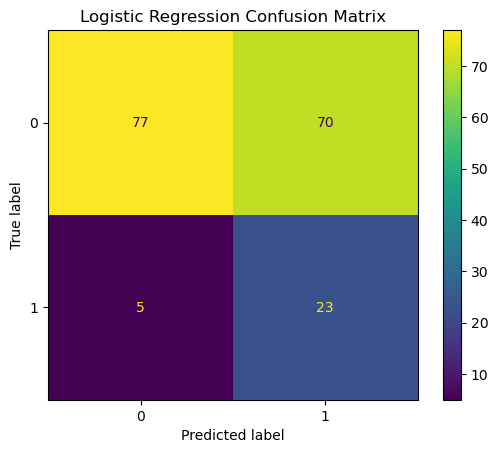

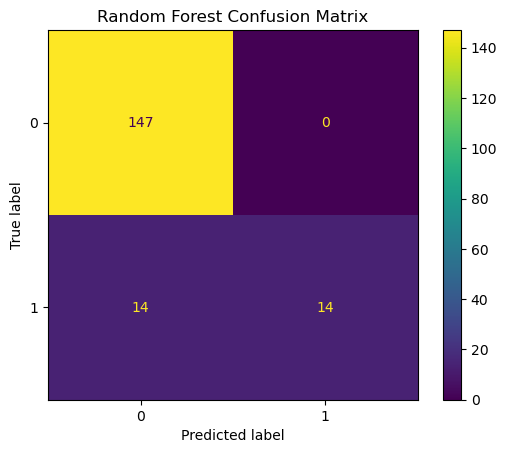

In [17]:
# Confusion matrices
ConfusionMatrixDisplay.from_estimator(logreg, X_test_scaled, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

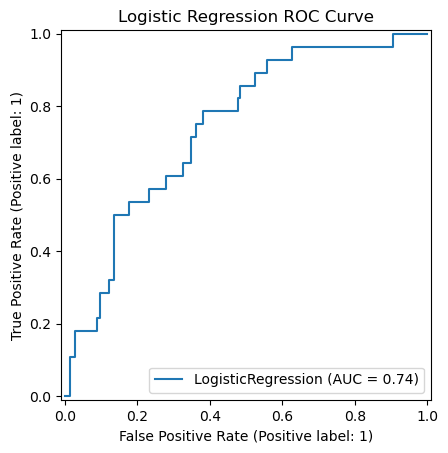

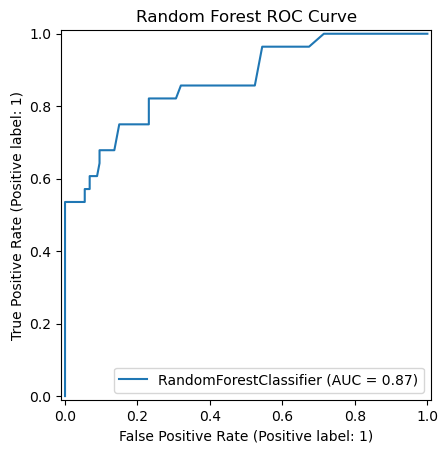

In [18]:
# ROC curves
RocCurveDisplay.from_estimator(logreg, X_test_scaled, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()

RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()

In [19]:
# Feature importances
feature_importances = pd.DataFrame({
    'feature': features_chart.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)
print("Random Forest Feature Importances for Billboard Charting Prediction:")
print(feature_importances)

Random Forest Feature Importances for Billboard Charting Prediction:
             feature  importance
10         track_pop    0.157411
9        duration_ms    0.092155
1             energy    0.090497
3        speechiness    0.088810
8              tempo    0.087761
6           liveness    0.081883
4       acousticness    0.079979
0       danceability    0.078893
7            valence    0.073396
2           loudness    0.071623
5   instrumentalness    0.058858
11             viral    0.038734


## 5. Results

In [20]:
# Time-Lag Analysis Summary

print("\nTime-Lag Analysis Summary")

if 'df_merged_unique' in globals() and not df_merged_unique.empty:
    print(f"Number of charted songs considered: {num_charted}")
    print(f"Mean lag (years): {mean_lag:.2f}")
    print(f"Median lag (years): {median_lag}")
    print(f"Min lag: {min_lag}, Max lag: {max_lag}")
    print(f"Songs charting BEFORE TikTok virality: {neg_lag_count}")
    print(f"Songs charting SAME YEAR as TikTok virality: {zero_lag_count}")
    print(f"Songs charting AFTER TikTok virality: {pos_lag_count}")
else:
    print("No charted songs matched TikTok dataset. Time-lag analysis unavailable.")

# Viral TikTok -> Billboard Probability

print("\nProbability of Viral TikTok Song Charting on Billboard")
print(f"P(Charted | Viral): {p_charted_given_viral:.2%}")

# Cross-Validation F1 Scores

print("\nCross-Validation F1 Scores (Training Set)")
print(f"Logistic Regression CV F1 scores: {logreg_cv_scores}")
print(f"Random Forest CV F1 scores: {rf_cv_scores}")
print(f"Average Logistic Regression F1: {logreg_cv_scores.mean():.4f}")
print(f"Average Random Forest F1: {rf_cv_scores.mean():.4f}")

# Grid Search Best Model Parameters

print("\nRandom Forest Hyperparameter Tuning (GridSearchCV)")
print(f"Best Parameters: {grid.best_params_}")
print(f"Best CV F1 Score: {grid.best_score_:.4f}")

# Test-Set Classification Reports

print("\nTest Set Classification Report: Logistic Regression")
print(classification_report(y_test, logreg.predict(X_test_scaled)))

print("\nTest Set Classification Report: Random Forest")
print(classification_report(y_test, rf.predict(X_test)))

# Feature Importances (Top 10)

print("\nRandom Forest Feature Importances (Top 10)")
top10 = feature_importances.head(10)
print(top10.to_string(index=False))


Time-Lag Analysis Summary
Number of charted songs considered: 260
Mean lag (years): -6.03
Median lag (years): -2.0
Min lag: -61.0, Max lag: 2.0
Songs charting BEFORE TikTok virality: 165
Songs charting SAME YEAR as TikTok virality: 76
Songs charting AFTER TikTok virality: 19

Probability of Viral TikTok Song Charting on Billboard
P(Charted | Viral): 24.42%

Cross-Validation F1 Scores (Training Set)
Logistic Regression CV F1 scores: [0.25       0.45238095 0.31818182 0.375      0.43956044]
Random Forest CV F1 scores: [0.35714286 0.4137931  0.5625     0.2962963  0.4137931 ]
Average Logistic Regression F1: 0.3670
Average Random Forest F1: 0.4087

Random Forest Hyperparameter Tuning (GridSearchCV)
Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best CV F1 Score: 0.4239

Test Set Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.52      0.67       147
           1       0.25      0.82      0.38        28


## 6. Discussion

The results provide several insights into the relationship between TikTok virality, Billboard chart performance, as well as the predictive power of audio features. The 'viral' label is defined as a TikTok track having a popularity score of 70 or higher. This threshold was chosen based on prior observations that tracks above this popularity score consistently demonstrate high engagement on the platform, making it a reasonable proxy for determining TikTok virality.

The time-lag analysis conducted reveals that most songs in the merged dataset charted on the Billboard Hot 100, but often years before they appeared in the TikTok dataset. Note that the main dataset for modeling uses Billboard entries from 2019-2022 to define charting status, while the time-lag analysis uses the full historical Billboard dataset. This allows us to capture songs that charted before 2019 and measure how TikTok revives older tracks, without affecting the model features or target variable. The mean lag of -6.03 years and median of -2 years indicate that TikTok frequently revives older tracks rather than breaking entirely new ones into the scene. Out of 260 charted songs analyzed, 165 charted in years before they went viral on TikTok, 76 charted the same year, and only 19 charted after. This supports the idea that TikTok is often more of a “re-discovery tool”, boosting existing catalog songs rather than generating new ones.

Despite TikTok’s promotional power, the probability that a viral TikTok track will appear on the Billboard Hot 100 is only 24.42%. This suggests that virality alone is not a strong enough predictor of chart success, as highlighted by the fact that many highly popular TikTok sounds do not translate into mainstream commercial performance. This supports the growing music industry concern that TikTok virality is often detached from full-length music consumption behavior, and therefore not reflective of real streaming patterns.

Model performance further illustrates this as well. Logistic Regression provides a relatively weak baseline, with an average F1 score of 0.3678, reflecting the difficulty of separating charting and non-charting songs linearly. Random Forest performs better, achieving an average CV F1 of 0.4087, and tuning improved this to 0.4239 with the best parameters (max_depth=10, n_estimators=100). On the held-out test set, Random Forest reaches 0.92 accuracy and an F1 score of 0.67 for charting songs, compared to 0.38 for Logistic Regression. The two models make very different tradeoffs: Logistic Regression catches more charting songs (recall of 0.82 vs. 0.50) but with low precision (0.25), while Random Forest identifies half of the charting songs with perfect precision (1.00).

Feature importance scores indicated that track popularity is the strongest predictor for charting success, followed by duration, energy, speechiness, and tempo. This suggests that Billboard performance is influenced by a combination of existing track traction and specific audio attributes. Viral status itself does not appear among the top predictors, reinforcing the finding that TikTok virality is only weakly related to Billboard success once other features are considered.

## 7. Conclusion

This project ultimately shows that while TikTok has become a dominant force in music discovery, its true impact on traditional chart performance and streaming success is much more nuanced than most assume. Looking at the findings, viral TikTok songs have only about a one-in-four chance of reaching the Billboard Hot 100, and time-lag patterns reveal that TikTok is often only amplifying tracks that were already commercially successful in prior years. Machine learning models trained on audio features, track popularity, and virality demonstrated moderate ability to predict Billboard charting success, with Random Forest outperforming Logistic Regression in both cross-validation and test-set performance. Overall, this study highlights both the power and the limits of TikTok as a predictor of mainstream music success.